In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install xgboost

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from xgboost import XGBRegressor
from pandas import DateOffset
from scipy.stats.mstats import winsorize

In [5]:
standardized = pd.read_csv("/content/drive/MyDrive/Quant-2026Fall/L10 XGBoost with Regression Trees/standardizedFeatures.csv.gz")
Returns = pd.read_csv("/content/drive/MyDrive/Quant-2026Fall/L5 Return Predictions/CRSP_monthly_returns_1995_2024.csv.gz")
Cstat = pd.read_csv("/content/drive/MyDrive/Quant-2026Fall/L5 Return Predictions/Compustat_characteristics_1995_2025.csv.gz")
rf = pd.read_excel("/content/drive/MyDrive/Quant-2026Fall/L5 Return Predictions/Market_Riskfree.xlsx")

In [ ]:
Data Cleaning

In [6]:
standardized["date"] = pd.to_datetime(standardized["date"], errors="coerce")
standardized["PERMNO"] = pd.to_numeric(standardized["PERMNO"], errors="coerce")

standardized = standardized.dropna(subset=["PERMNO", "date"]).copy()
standardized["PERMNO"] = standardized["PERMNO"].astype(int)

standardized = standardized.sort_values(["date", "PERMNO"]).reset_index(drop=True)

print(standardized.columns.tolist())
standardized.head()

['date', 'marketcap_pct_rank', 'new_issue_pct_rank', 'investment_pct_rank', 'accruals_pct_rank', 'b2m_pct_rank', 'ret_2_12_pct_rank', 'CashFlow2TA_pct_rank', 'CashFlow2Prc_pct_rank', 'RET', 'PERMNO']


,date,marketcap_pct_rank,new_issue_pct_rank,investment_pct_rank,accruals_pct_rank,b2m_pct_rank,ret_2_12_pct_rank,CashFlow2TA_pct_rank,CashFlow2Prc_pct_rank,RET,PERMNO
0,1992-06-30,0.416667,0.083333,0.500000,0.750000,0.666667,0.083333,0.500000,0.416667,-0.106383,10779
1,1992-06-30,0.500000,0.750000,1.000000,0.666667,0.333333,0.583333,0.166667,0.166667,-0.025641,10986
2,1992-06-30,0.333333,0.250000,0.333333,0.500000,1.000000,0.916667,0.333333,0.500000,-0.066667,19546
3,1992-06-30,1.000000,1.000000,0.666667,0.583333,0.166667,0.666667,0.666667,0.583333,-0.046512,28388
4,1992-06-30,0.916667,0.833333,0.833333,0.916667,0.583333,0.833333,0.250000,0.250000,-0.171429,29496


In [7]:
Returns["date"] = pd.to_datetime(Returns["date"], errors="coerce")
Returns["PERMNO"] = pd.to_numeric(Returns["PERMNO"], errors="coerce")
Returns["RET"] = pd.to_numeric(Returns["RET"], errors="coerce")

Returns = Returns.dropna(subset=["PERMNO", "date", "RET"]).copy()
Returns["PERMNO"] = Returns["PERMNO"].astype(int)

Returns["year"] = Returns["date"].dt.year
Returns["month"] = Returns["date"].dt.month

Returns = Returns.sort_values(["date", "PERMNO"]).reset_index(drop=True)

Returns.head()

,Unnamed: 0,PERMNO,date,RET,PRC,SHROUT,CFACPR,CFACSHR,SHRCD,PRIMEXCH,year,month
0,0,10001,1990-01-31,-0.018519,-9.93750,1022.0,3.0,3.0,11,Q,1990,1
1,1,10002,1990-01-31,0.020408,-6.25000,1175.0,1.5,1.5,10,Q,1990,1
2,2,10003,1990-01-31,-0.088235,7.75000,2194.0,1.0,1.0,11,Q,1990,1
3,3,10005,1990-01-31,0.000000,-0.06250,8376.0,1.0,1.0,10,Q,1990,1
4,4,10007,1990-01-31,-0.474886,-3.59375,4120.0,1.0,1.0,10,Q,1990,1


In [8]:
Cstat = Cstat.rename(columns={"LPERMNO": "PERMNO"})

Cstat["datadate"] = pd.to_datetime(Cstat["datadate"], errors="coerce")
Cstat["PERMNO"] = pd.to_numeric(Cstat["PERMNO"], errors="coerce")

Cstat = Cstat.dropna(subset=["PERMNO", "datadate"]).copy()
Cstat["PERMNO"] = Cstat["PERMNO"].astype(int)

for col in ["at", "ib", "ni", "lt"]:
    if col in Cstat.columns:
        Cstat[col] = pd.to_numeric(Cstat[col], errors="coerce")

Cstat = Cstat.sort_values(["PERMNO", "datadate"]).copy()

**Q1(1) New Features**

**ROA** captures firm profitability. More profitable firms may have stronger business quality and better future performance, so ROA may help predict cross-sectional stock returns.

**Equity ratio** captures balance-sheet strength. Firms with a higher share of equity financing are generally less financially fragile, so this feature may contain information about future returns that is not fully reflected in prices.

In [12]:
# new feature 1: ROA
Cstat["lag_at"] = Cstat.groupby("PERMNO")["at"].shift(1)
Cstat["roa"] = Cstat["ib"] / Cstat["lag_at"]

# new feature 2: equity ratio
Cstat["equity_ratio"] = Cstat["ceq"] / Cstat["at"]

# make accounting information investable after 6 months
Cstat["date"] = pd.to_datetime(Cstat["datadate"], errors="coerce") + DateOffset(months=6)

Cstat.head()

,Unnamed: 0,gvkey,datadate,ceq,ib,oancf,at,PERMNO,linkdt,linkenddt,lag_at,roa,equity_ratio,date
103950,103950,12994,1990-06-30,7.179,1.131,1.894,18.881,10001,1986-01-09,2017-08-31,NaN,NaN,0.380224,1990-12-30
103951,103951,12994,1991-06-30,7.982,1.073,1.954,19.599,10001,1986-01-09,2017-08-31,18.881,0.056830,0.407266,1991-12-30
103952,103952,12994,1992-06-30,8.171,0.834,2.364,22.286,10001,1986-01-09,2017-08-31,19.599,0.042553,0.366643,1992-12-30
103953,103953,12994,1993-06-30,8.733,1.284,1.464,27.434,10001,1986-01-09,2017-08-31,22.286,0.057615,0.318328,1993-12-30
103954,103954,12994,1994-06-30,9.393,1.259,2.851,28.095,10001,1986-01-09,2017-08-31,27.434,0.045892,0.334330,1994-12-30


**Q5 Dealing with outliers**

Outliers may affect model performance by making accounting-based features excessively extreme and reducing the stability of stock rankings. This is especially relevant for ratio variables such as ROA and Equity Ratio. However, because XGBoost is tree-based, it is generally less sensitive to outliers than linear models.

In [13]:
def winsorize_by_date(df, col, lower=0.01, upper=0.01):
    def _w(x):
        if x.notna().sum() < 5:
            return x
        arr = x.to_numpy(dtype=float)
        mask = np.isfinite(arr)
        out = arr.copy()
        out[mask] = winsorize(arr[mask], limits=[lower, upper])
        return pd.Series(out, index=x.index)
    return df.groupby("date")[col].transform(_w)

Cstat = Cstat.dropna(subset=["date"]).copy()

for col in ["roa", "equity_ratio"]:
    Cstat[col] = winsorize_by_date(Cstat, col)

In [14]:
for col in ["roa", "equity_ratio"]:
    Cstat[col + "_pct_rank"] = Cstat.groupby("date")[col].rank(pct=True)

In [17]:
new_features = Cstat[["PERMNO", "date", "roa_pct_rank", "equity_ratio_pct_rank"]].copy()

new_features["PERMNO"] = pd.to_numeric(new_features["PERMNO"], errors="coerce")
new_features["date"] = pd.to_datetime(new_features["date"], errors="coerce")

new_features["roa_pct_rank"] = pd.to_numeric(new_features["roa_pct_rank"], errors="coerce")
new_features["equity_ratio_pct_rank"] = pd.to_numeric(new_features["equity_ratio_pct_rank"], errors="coerce")

new_features = new_features.dropna(subset=["PERMNO", "date"]).copy()
new_features["PERMNO"] = new_features["PERMNO"].astype(int)

# collapse duplicates to unique PERMNO-date
new_features = (
    new_features
    .groupby(["PERMNO", "date"], as_index=False)[["roa_pct_rank", "equity_ratio_pct_rank"]]
    .mean()
)

new_features = new_features.sort_values(["date", "PERMNO"]).reset_index(drop=True)

new_features.head()

,PERMNO,date,roa_pct_rank,equity_ratio_pct_rank
0,10077,1990-07-31,0.333333,0.775862
1,10178,1990-07-31,NaN,0.762931
2,10182,1990-07-31,NaN,0.375000
3,10185,1990-07-31,0.288889,0.625000
4,10222,1990-07-31,0.633333,0.685345


In [18]:
base = standardized.copy()

base["PERMNO"] = pd.to_numeric(base["PERMNO"], errors="coerce")
base["date"] = pd.to_datetime(base["date"], errors="coerce")
base = base.dropna(subset=["PERMNO", "date"]).copy()
base["PERMNO"] = base["PERMNO"].astype(int)
base = base.sort_values(["date", "PERMNO"]).reset_index(drop=True)

new_features["PERMNO"] = pd.to_numeric(new_features["PERMNO"], errors="coerce")
new_features["date"] = pd.to_datetime(new_features["date"], errors="coerce")
new_features = new_features.dropna(subset=["PERMNO", "date"]).copy()
new_features["PERMNO"] = new_features["PERMNO"].astype(int)
new_features = new_features.sort_values(["date", "PERMNO"]).reset_index(drop=True)

model_df = pd.merge(
    base,
    new_features,
    on=["PERMNO", "date"],
    how="left",
    validate="m:1"
)

model_df.head()

,date,marketcap_pct_rank,new_issue_pct_rank,investment_pct_rank,accruals_pct_rank,b2m_pct_rank,ret_2_12_pct_rank,CashFlow2TA_pct_rank,CashFlow2Prc_pct_rank,RET,PERMNO,roa_pct_rank,equity_ratio_pct_rank
0,1992-06-30,0.416667,0.083333,0.500000,0.750000,0.666667,0.083333,0.500000,0.416667,-0.106383,10779,0.563727,0.526331
1,1992-06-30,0.500000,0.750000,1.000000,0.666667,0.333333,0.583333,0.166667,0.166667,-0.025641,10986,0.005202,0.943941
2,1992-06-30,0.333333,0.250000,0.333333,0.500000,1.000000,0.916667,0.333333,0.500000,-0.066667,19546,0.183022,0.883352
3,1992-06-30,1.000000,1.000000,0.666667,0.583333,0.166667,0.666667,0.666667,0.583333,-0.046512,28388,0.620005,0.051954
4,1992-06-30,0.916667,0.833333,0.833333,0.916667,0.583333,0.833333,0.250000,0.250000,-0.171429,29496,0.310002,0.409966


In [19]:
Returns_sub = Returns[["PERMNO", "date", "RET"]].copy()

Returns_sub["PERMNO"] = pd.to_numeric(Returns_sub["PERMNO"], errors="coerce")
Returns_sub["date"] = pd.to_datetime(Returns_sub["date"], errors="coerce")
Returns_sub["RET"] = pd.to_numeric(Returns_sub["RET"], errors="coerce")

Returns_sub = Returns_sub.dropna(subset=["PERMNO", "date", "RET"]).copy()
Returns_sub["PERMNO"] = Returns_sub["PERMNO"].astype(int)

Returns_sub = Returns_sub.sort_values(["date", "PERMNO"]).reset_index(drop=True)

model_df = pd.merge(
    model_df,
    Returns_sub,
    on=["PERMNO", "date"],
    how="left",
    validate="1:1"
)

model_df["yr"] = model_df["date"].dt.year
model_df["month"] = model_df["date"].dt.month

model_df.head()

,date,marketcap_pct_rank,new_issue_pct_rank,investment_pct_rank,accruals_pct_rank,b2m_pct_rank,ret_2_12_pct_rank,CashFlow2TA_pct_rank,CashFlow2Prc_pct_rank,RET_x,PERMNO,roa_pct_rank,equity_ratio_pct_rank,RET_y,yr,month
0,1992-06-30,0.416667,0.083333,0.500000,0.750000,0.666667,0.083333,0.500000,0.416667,-0.106383,10779,0.563727,0.526331,-0.106383,1992,6
1,1992-06-30,0.500000,0.750000,1.000000,0.666667,0.333333,0.583333,0.166667,0.166667,-0.025641,10986,0.005202,0.943941,-0.025641,1992,6
2,1992-06-30,0.333333,0.250000,0.333333,0.500000,1.000000,0.916667,0.333333,0.500000,-0.066667,19546,0.183022,0.883352,-0.066667,1992,6
3,1992-06-30,1.000000,1.000000,0.666667,0.583333,0.166667,0.666667,0.666667,0.583333,-0.046512,28388,0.620005,0.051954,-0.046512,1992,6
4,1992-06-30,0.916667,0.833333,0.833333,0.916667,0.583333,0.833333,0.250000,0.250000,-0.171429,29496,0.310002,0.409966,-0.171429,1992,6


In [22]:
# resolve duplicated RET columns after merge
if "RET_y" in model_df.columns:
    model_df["RET"] = model_df["RET_y"]
elif "RET_x" in model_df.columns:
    model_df["RET"] = model_df["RET_x"]

drop_cols = [c for c in ["RET_x", "RET_y"] if c in model_df.columns]
model_df = model_df.drop(columns=drop_cols)

model_df["yr"] = model_df["date"].dt.year
model_df["month"] = model_df["date"].dt.month

Feature & Target Definition

In [20]:
feature_cols = [
    "marketcap_pct_rank",
    "new_issue_pct_rank",
    "investment_pct_rank",
    "accruals_pct_rank",
    "b2m_pct_rank",
    "ret_2_12_pct_rank",
    "CashFlow2TA_pct_rank",
    "CashFlow2Prc_pct_rank",
    "roa_pct_rank",
    "equity_ratio_pct_rank"
]

In [24]:
model_df["target_ret"] = pd.to_numeric(model_df["RET"], errors="coerce")

In [25]:
needed_cols = ["PERMNO", "date", "yr", "month", "RET", "target_ret"] + feature_cols
model_data = model_df[needed_cols].copy()

In [26]:
needed_cols = ["PERMNO", "date", "yr", "month", "RET", "target_ret"] + feature_cols
model_data = model_df[needed_cols].copy()

for c in ["RET", "target_ret"] + feature_cols:
    model_data[c] = pd.to_numeric(model_data[c], errors="coerce")

model_data = model_data.dropna(subset=["date", "PERMNO", "target_ret"] + feature_cols).copy()

model_data = model_data.sort_values(["date", "PERMNO"]).reset_index(drop=True)

model_data["month_num"] = model_data["date"].rank(method="dense").astype(int)

model_data.head()

,PERMNO,date,yr,month,RET,target_ret,marketcap_pct_rank,new_issue_pct_rank,investment_pct_rank,accruals_pct_rank,b2m_pct_rank,ret_2_12_pct_rank,CashFlow2TA_pct_rank,CashFlow2Prc_pct_rank,roa_pct_rank,equity_ratio_pct_rank,month_num
0,10779,1992-06-30,1992,6,-0.106383,-0.106383,0.416667,0.083333,0.500000,0.750000,0.666667,0.083333,0.500000,0.416667,0.563727,0.526331,1
1,10986,1992-06-30,1992,6,-0.025641,-0.025641,0.500000,0.750000,1.000000,0.666667,0.333333,0.583333,0.166667,0.166667,0.005202,0.943941,1
2,19546,1992-06-30,1992,6,-0.066667,-0.066667,0.333333,0.250000,0.333333,0.500000,1.000000,0.916667,0.333333,0.500000,0.183022,0.883352,1
3,28388,1992-06-30,1992,6,-0.046512,-0.046512,1.000000,1.000000,0.666667,0.583333,0.166667,0.666667,0.666667,0.583333,0.620005,0.051954,1
4,29496,1992-06-30,1992,6,-0.171429,-0.171429,0.916667,0.833333,0.833333,0.916667,0.583333,0.833333,0.250000,0.250000,0.310002,0.409966,1


**Q1(2) XGBoost Prediction**

In [27]:
predicted_ret_df = pd.DataFrame()

rolling_window = 60
max_month = int(model_data["month_num"].max())

for test_month in range(rolling_window + 1, max_month + 1):
    train_start = test_month - rolling_window
    train_end = test_month - 1

    train_data = model_data[
        (model_data["month_num"] >= train_start) &
        (model_data["month_num"] <= train_end)
    ].copy()

    test_data = model_data[
        model_data["month_num"] == test_month
    ].copy()

    if len(train_data) == 0 or len(test_data) == 0:
        continue

    X_train = train_data[feature_cols]
    y_train = train_data["target_ret"]

    X_test = test_data[feature_cols]

    model = XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)
    test_data["predicted_ret"] = model.predict(X_test)

    keep_cols = ["PERMNO", "date", "yr", "month", "RET", "predicted_ret"] + feature_cols
    predicted_ret_df = pd.concat([predicted_ret_df, test_data[keep_cols]], axis=0)

predicted_ret_df = predicted_ret_df.reset_index(drop=True)
predicted_ret_df.head()

,PERMNO,date,yr,month,RET,predicted_ret,marketcap_pct_rank,new_issue_pct_rank,investment_pct_rank,accruals_pct_rank,b2m_pct_rank,ret_2_12_pct_rank,CashFlow2TA_pct_rank,CashFlow2Prc_pct_rank,roa_pct_rank,equity_ratio_pct_rank
0,10042,2003-06-30,2003,6,0.097561,0.006128,0.102809,0.890750,0.117238,0.479000,0.793610,0.193249,0.150992,0.119299,0.203718,0.847863
1,10085,2003-06-30,2003,6,0.051640,0.013054,0.675341,0.115177,0.765782,0.564545,0.731770,0.328008,0.487503,0.930688,0.583070,0.341838
2,10119,2003-06-30,2003,6,0.011315,0.001110,0.772481,0.321824,0.684360,0.545736,0.484927,0.312548,0.402989,0.434682,0.323049,0.625400
3,10137,2003-06-30,2003,6,-0.027618,-0.001948,0.757021,0.548570,0.338057,0.438031,0.931461,0.033239,0.319248,0.886369,0.260680,0.360572
4,10138,2003-06-30,2003,6,0.033506,0.017001,0.907756,0.164391,0.584901,0.584385,0.208709,0.559650,0.906210,0.422056,0.962619,0.929298


Decile Split

In [28]:
predicted_ret_df["rank_order"] = predicted_ret_df.groupby(["yr", "month"])["predicted_ret"] \
    .rank(method="first")

predicted_ret_df["decile"] = predicted_ret_df.groupby(["yr", "month"])["rank_order"] \
    .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates="drop") + 1)

predicted_ret_df["decile"] = predicted_ret_df["decile"].astype(int)

predicted_ret_df.head()

,PERMNO,date,yr,month,RET,predicted_ret,marketcap_pct_rank,new_issue_pct_rank,investment_pct_rank,accruals_pct_rank,b2m_pct_rank,ret_2_12_pct_rank,CashFlow2TA_pct_rank,CashFlow2Prc_pct_rank,roa_pct_rank,equity_ratio_pct_rank,rank_order,decile
0,10042,2003-06-30,2003,6,0.097561,0.006128,0.102809,0.890750,0.117238,0.479000,0.793610,0.193249,0.150992,0.119299,0.203718,0.847863,489.0,4
1,10085,2003-06-30,2003,6,0.051640,0.013054,0.675341,0.115177,0.765782,0.564545,0.731770,0.328008,0.487503,0.930688,0.583070,0.341838,756.0,5
2,10119,2003-06-30,2003,6,0.011315,0.001110,0.772481,0.321824,0.684360,0.545736,0.484927,0.312548,0.402989,0.434682,0.323049,0.625400,318.0,2
3,10137,2003-06-30,2003,6,-0.027618,-0.001948,0.757021,0.548570,0.338057,0.438031,0.931461,0.033239,0.319248,0.886369,0.260680,0.360572,237.0,2
4,10138,2003-06-30,2003,6,0.033506,0.017001,0.907756,0.164391,0.584901,0.584385,0.208709,0.559650,0.906210,0.422056,0.962619,0.929298,903.0,6


decile return & long-short return

In [29]:
decile_ret = predicted_ret_df.groupby(["yr", "month", "decile"])["RET"].mean().reset_index()

wide_ret = decile_ret.pivot(index=["yr", "month"], columns="decile", values="RET").copy()

wide_ret["LS"] = wide_ret[10] - wide_ret[1]

wide_ret.head()

decile             1         2         3         4         5         6  \
yr   month                                                               
2003 6      0.083397  0.063310  0.052458  0.029139  0.046473  0.016471   
     7      0.142870  0.061499  0.012755  0.007180  0.094414  0.056015   
     9      0.014846  0.066760  0.120516  0.028402  0.094004  0.022926   
2004 4     -0.046353  0.011410 -0.009563 -0.070824 -0.040419  0.048705   
     6      0.018271  0.023803  0.014338  0.024742  0.042992  0.054906   

decile             7         8         9        10        LS  
yr   month                                                    
2003 6      0.025847  0.021965  0.044184  0.084339  0.000943  
     7      0.153545  0.138305 -0.022838  0.287609  0.144738  
     9      0.019795  0.017501 -0.004988  0.036735  0.021889  
2004 4     -0.037576 -0.073966 -0.032338 -0.067147 -0.020794  
     6      0.030994  0.045201  0.038556 -0.027481 -0.045752

**Q2 Returns of decile portfolio**

In [30]:
summary_list = []

for col in list(range(1, 11)) + ["LS"]:
    temp = wide_ret[col].dropna()
    mean_ret = temp.mean()
    std_ret = temp.std()
    n = temp.count()
    t_stat = mean_ret / (std_ret / np.sqrt(n)) if std_ret > 0 else np.nan

    summary_list.append([col, mean_ret, std_ret, n, t_stat])

summary_table = pd.DataFrame(summary_list, columns=["Portfolio", "Mean", "Std", "N", "t_stat"])
summary_table

,Portfolio,Mean,Std,N,t_stat
0,1,0.002032,0.086113,119,0.257426
1,2,0.011745,0.072473,119,1.767945
2,3,0.018564,0.087645,119,2.310539
3,4,0.014963,0.078834,118,2.061811
4,5,0.014606,0.072283,119,2.204358
5,6,0.020562,0.086382,119,2.596719
6,7,0.015047,0.080604,118,2.027910
7,8,0.014501,0.073320,119,2.157497
8,9,0.012628,0.080882,119,1.703188
9,10,0.011413,0.100508,119,1.238734


In [33]:
print(rf.columns.tolist())

['year', 'month', 'Mkt', 'RF']


In [34]:
rf = rf.rename(columns={
    "year": "yr",
    "month": "month",
    "RF": "RF",
    "Mkt": "Mkt"
})

**Q3 Performance Evaluation**

In [35]:
perf_df = wide_ret.reset_index().merge(rf, on=["yr", "month"], how="left")

perf_list = []

for col in list(range(1, 11)) + ["LS"]:
    temp = perf_df[[col, "RF", "Mkt"]].dropna().copy()

    temp["excess"] = temp[col] - temp["RF"]
    temp["active"] = temp[col] - temp["Mkt"]

    sharpe = np.sqrt(12) * temp["excess"].mean() / temp["excess"].std() if temp["excess"].std() > 0 else np.nan
    info_ratio = np.sqrt(12) * temp["active"].mean() / temp["active"].std() if temp["active"].std() > 0 else np.nan

    perf_list.append([col, sharpe, info_ratio])

perf_metrics = pd.DataFrame(perf_list, columns=["Portfolio", "Sharpe", "Information_Ratio"])
perf_metrics

,Portfolio,Sharpe,Information_Ratio
0,1,0.030369,-0.505842
1,2,0.500572,-0.032225
2,3,0.683902,0.287016
3,4,0.600894,0.153630
4,5,0.637596,0.155531
5,6,0.773554,0.366408
6,7,0.590423,0.143549
7,8,0.625339,0.140775
8,9,0.485670,0.018487
9,10,0.349079,-0.034201


In [36]:
final_perf = summary_table.merge(perf_metrics, on="Portfolio", how="left")
final_perf

,Portfolio,Mean,Std,N,t_stat,Sharpe,Information_Ratio
0,1,0.002032,0.086113,119,0.257426,0.030369,-0.505842
1,2,0.011745,0.072473,119,1.767945,0.500572,-0.032225
2,3,0.018564,0.087645,119,2.310539,0.683902,0.287016
3,4,0.014963,0.078834,118,2.061811,0.600894,0.153630
4,5,0.014606,0.072283,119,2.204358,0.637596,0.155531
5,6,0.020562,0.086382,119,2.596719,0.773554,0.366408
6,7,0.015047,0.080604,118,2.027910,0.590423,0.143549
7,8,0.014501,0.073320,119,2.157497,0.625339,0.140775
8,9,0.012628,0.080882,119,1.703188,0.485670,0.018487
9,10,0.011413,0.100508,119,1.238734,0.349079,-0.034201


**Q4 Market-neutral evaluation**

To test market neutrality, I regressed the excess return of the long-short portfolio on market excess return using a CAPM specification. The estimated market beta is -0.0083 with a p-value of 0.971, which is economically close to zero and statistically insignificant. Therefore, the long-minus-short portfolio appears approximately market-neutral.

In [37]:
ls_df = perf_df[["yr", "month", "LS", "RF", "Mkt"]].dropna().copy()

ls_df["ls_excess"] = ls_df["LS"] - ls_df["RF"]
ls_df["mkt_excess"] = ls_df["Mkt"] - ls_df["RF"]

X = sm.add_constant(ls_df["mkt_excess"])
y = ls_df["ls_excess"]

capm_model = sm.OLS(y, X).fit()
print(capm_model.summary())

                            OLS Regression Results                            
Dep. Variable:              ls_excess   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                  0.001346
Date:                Thu, 16 Apr 2026   Prob (F-statistic):              0.971
Time:                        02:15:26   Log-Likelihood:                 103.05
No. Observations:                 119   AIC:                            -202.1
Df Residuals:                     117   BIC:                            -196.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0082      0.010      0.842      0.4

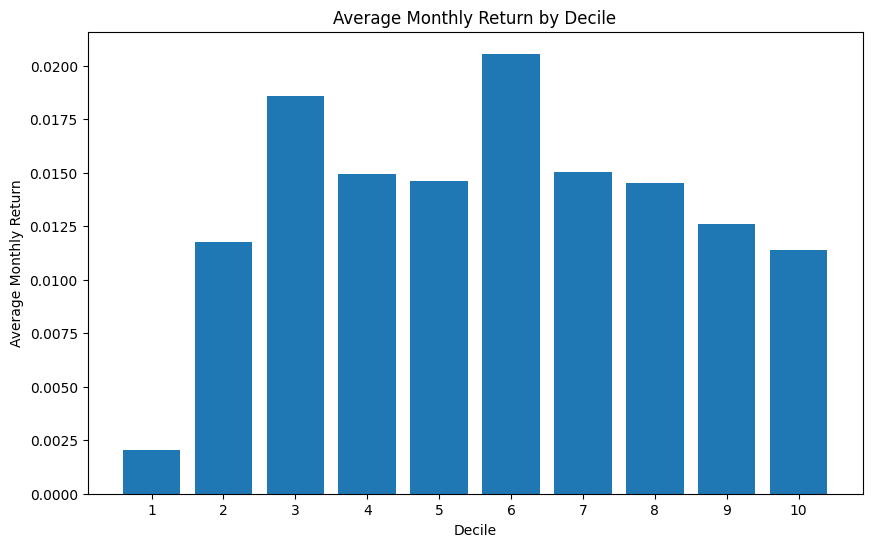

In [38]:
plot_df = final_perf[final_perf["Portfolio"] != "LS"].copy()

plt.figure(figsize=(10, 6))
plt.bar(plot_df["Portfolio"].astype(str), plot_df["Mean"])
plt.title("Average Monthly Return by Decile")
plt.xlabel("Decile")
plt.ylabel("Average Monthly Return")
plt.show()

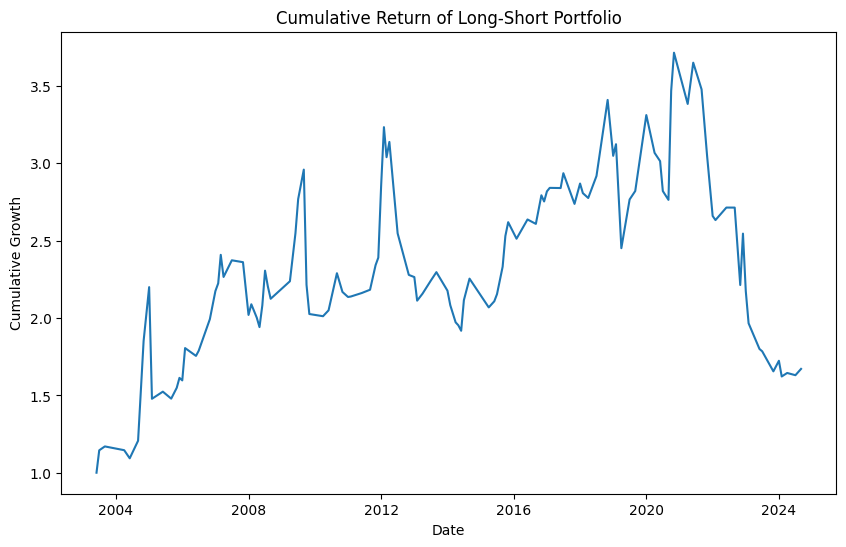

In [39]:
ls_plot = wide_ret.reset_index()[["yr", "month", "LS"]].dropna().copy()
ls_plot["date"] = pd.to_datetime(ls_plot["yr"].astype(str) + "-" + ls_plot["month"].astype(str) + "-01")
ls_plot = ls_plot.sort_values("date")

ls_plot["cumret"] = (1 + ls_plot["LS"]).cumprod()

plt.figure(figsize=(10, 6))
plt.plot(ls_plot["date"], ls_plot["cumret"])
plt.title("Cumulative Return of Long-Short Portfolio")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.show()

In [40]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
9,equity_ratio_pct_rank,0.141869
6,CashFlow2TA_pct_rank,0.116307
2,investment_pct_rank,0.114503
1,new_issue_pct_rank,0.109354
5,ret_2_12_pct_rank,0.104065
4,b2m_pct_rank,0.095441
7,CashFlow2Prc_pct_rank,0.082723
0,marketcap_pct_rank,0.080288
3,accruals_pct_rank,0.079460
8,roa_pct_rank,0.075990


In [41]:
print("Raw Returns sample:", Returns["date"].min(), "to", Returns["date"].max())
print("Raw Cstat sample:", Cstat["datadate"].min(), "to", Cstat["datadate"].max())

print("Model data sample:", model_data["date"].min(), "to", model_data["date"].max())
print("Prediction sample:", predicted_ret_df["date"].min(), "to", predicted_ret_df["date"].max())

Raw Returns sample: 1990-01-31 00:00:00 to 2024-12-31 00:00:00
Raw Cstat sample: 1990-01-31 00:00:00 to 2025-12-31 00:00:00
Model data sample: 1992-06-30 00:00:00 to 2024-09-30 00:00:00
Prediction sample: 2003-06-30 00:00:00 to 2024-09-30 00:00:00
